# ICT-12b — Valence APPRISE, transferable, reversible : l'expérience manquante (#7740)

**Sous-série ICT** (trajectoires intégrées, Epic #4588, strate 3). Notebook compagnon d'[ICT-12](ICT-12-ValenceFieldsAndAnimats.ipynb).

## Le point de départ : ICT-12 programme la valence

Dans [ICT-12](ICT-12-ValenceFieldsAndAnimats.ipynb), la **source** a une valence *intrinsèque* parce que le schéma la place là : le champ gaussien attractif est **donné d'entrée**. C'est la lecture **programmée** de la valence (`valence_at`).

La question #7740 est l'envers exact : une valence qui est

- **apprise** — acquise par conditionnement pavlovien, pas inscrite dans le schéma ;
- **transférable** — un signal d'abord *neutre* devient *attractif* après association répétée avec une source biologiquement pertinente ;
- **distincte de la représentation prédictive** — `p̂` *prédit où est* la source ; `π` encode combien l'agent **investit** dans un signal.

Ces deux lectures coexistent sans se confondre. Ici on outille la seconde (module `ict/learned_valence.py`, mergé #8823) : une règle de type **Rescorla-Wagner** où le changement de valence est proportionnel à l'**erreur de prédiction**, pas à la simple co-occurrence.

## La règle Rescorla-Wagner

$$\Delta \pi_i = \mathrm{lr} \cdot (v_\text{source} - \pi_i)$$

- `source_valence > 0` et signal co-occurrent : $\pi_i$ monte vers $v_\text{source}$ (**acquisition**) ;
- `source_valence = 0` (signal présenté seul) : $\pi_i$ décroît vers 0 (**extinction**).

Le fait qu'acquisition et extinction partagent la **même règle** (l'erreur de prédiction) est précisément ce qui rend la valence *réversible* — pas deux systèmes, un seul qui s'adapte au signe de l'erreur. C'est la différence avec un simple compteur d'apparitions (qui ne s'éteindrait jamais).


In [1]:
import sys, os
sys.path.insert(0, os.getcwd())  # ICT-Series/ pour `from ict import ...`

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from ict.learned_valence import (
    LearnedValence,
    valence_transfer_test,
    valence_prediction_distinctness_test,
    extinction_test,
)

matplotlib.rcParams.update({"figure.dpi": 110, "font.size": 10})
rng = np.random.default_rng(0)
print("module ict.learned_valence charge (Rescorla-Wagner, #7740).")


module ict.learned_valence charge (Rescorla-Wagner, #7740).


## 1. La valence apprise — du neutre à l'attractif

À l'initialisation, **aucun** signal n'est attractif : $\pi = 0$ pour tout. C'est par construction — rien n'est investi avant tout apprentissage. Conditionnons un signal neutre en le présentant répétitivement avec une source pertinente ($v_\text{source} = 1$) et observons sa valence monter vers 1.


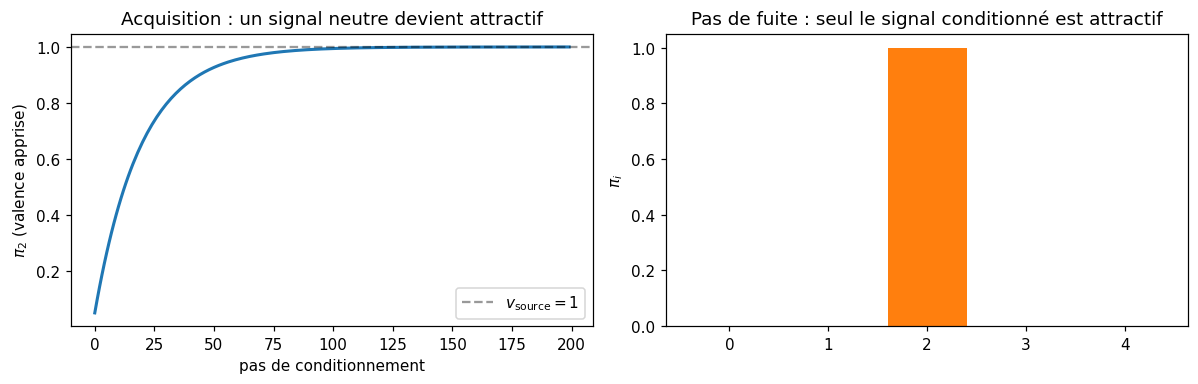

pi_2 final = 1.0000 (cible 1.0) ; autres signaux = [0.0, 0.0, 0.0, 0.0]


In [2]:
# Conditionnement : le signal 2 est neutre, puis co-occurre avec une source (valence 1).
lv = LearnedValence(n_signals=5, lr=0.05)
trace = []
for step in range(200):
    lv.condition(2, source_valence=1.0, steps=1)
    trace.append(lv.valence(2))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(trace, lw=2)
ax[0].axhline(1.0, ls="--", color="k", alpha=0.4, label=r"$v_\mathrm{source}=1$")
ax[0].set_xlabel("pas de conditionnement")
ax[0].set_ylabel(r"$\pi_2$ (valence apprise)")
ax[0].set_title("Acquisition : un signal neutre devient attractif")
ax[0].legend()

# Vecteur pi final : seul le signal 2 a monté (pas de fuite vers les autres).
ax[1].bar(range(5), lv.valence_vector(), color="C1")
ax[1].set_xticks(range(5))
ax[1].set_ylabel(r"$\pi_i$")
ax[1].set_title("Pas de fuite : seul le signal conditionné est attractif")
plt.tight_layout()
plt.show()
print(f"pi_2 final = {lv.valence(2):.4f} (cible 1.0) ; autres signaux = {lv.valence_vector()[[0,1,3,4]].tolist()}")


## 2. Le verdict de TRANSFERT

L'enjeu n'est pas qu'un signal monte quand on le renforce — c'est qu'il devienne attractif **par lui-même**, présenté seul. Et cruciallement : un signal *jamais associé* doit rester neutre. Sinon ce n'est pas du transfert, c'est une **fuite** de l'inné vers tout.

Le banc `valence_transfer_test` rend ce verdict falsifiable : `transferred` est vrai ssi le neutre devient attractif ($\pi > 0.5$) **et** le contrôle reste neutre ($\pi < 0.05$).


In [3]:
report = valence_transfer_test(
    n_signals=4, pertinent_idx=0, neutral_idx=1,
    source_valence=1.0, n_condition=50, lr=0.1,
)
print("Verdict TRANSFERT :")
for k, v in report.items():
    print(f"  {k:32} = {v:.4f}")
print(f"\n=> transferred = {report['transferred']:.1f} "
      f"(neutre {report['pre_valence_neutral']:.2f} -> {report['post_valence_neutral']:.2f}, "
      f"controle non-conditionne {report['control_valence_unconditioned']:.3f})")


Verdict TRANSFERT :
  pre_valence_neutral              = 0.0000
  post_valence_neutral             = 0.9948
  transfer_gain                    = 0.9948
  control_valence_unconditioned    = 0.0000
  n_condition                      = 50.0000
  transferred                      = 1.0000

=> transferred = 1.0 (neutre 0.00 -> 0.99, controle non-conditionne 0.000)


## 3. Le verdict de DISTINCTNESS — valence $\neq$ prédiction

Le cœur falsifiable de #7740 : $\pi$ (valence) et $p̂$ (prédiction) doivent pouvoir **diverger**. Si la valence apprise n'était qu'un re-vêtement de la prédiction, l'expérience manquante serait vide.

Le banc `valence_prediction_distinctness_test` accepte un prédicteur sous deux arités :

- `predict_fn(i)` — **state-invariant** : la prédiction ne lit pas la valence. Son erreur ne change pas entre avant et après conditionnement, donc $\Delta_\mathrm{err} \approx 0$ $\Rightarrow$ `distinct = 1`.
- `predict_fn(i, pi_t)` — **state-coupled** : peut lire la valence. Un re-vêtement parfait `p̂ = 1 - π_i` voit son erreur suivre $\pi$ (avant $\pi{=}0 \Rightarrow$ err 1 ; après $\pi{\approx}1 \Rightarrow$ err 0), donc $\Delta_\mathrm{err} > 0$ $\Rightarrow$ `distinct = 0`.

C'est ce passage du vecteur $\pi_t$ au prédicteur qui rend le banc **réellement réfutable** (revue ai-01 #8823) : sans lui, le verdict était satisfait par construction pour toute fonction pure.


In [4]:
# Predicteur state-INVARIANT (1 arg) : l'erreur ne depend pas de la valence -> distinct.
def predict_invariant(signal_idx: int) -> float:
    # Le signal 1 est mal predit (erreur 0.4), invariant au conditionnement.
    return 0.4 if signal_idx == 1 else 0.1

# Predicteur state-COUPLED (2 args) : re-vetement p_hat = 1 - pi -> erreur suit pi -> NON distinct.
def predict_coupled(signal_idx: int, pi_t) -> float:
    return 1.0 - pi_t[signal_idx]

rep_inv = valence_prediction_distinctness_test(
    predict_fn=predict_invariant, n_signals=4, conditioned_idx=1,
    source_valence=1.0, n_condition=50, lr=0.1,
)
rep_coup = valence_prediction_distinctness_test(
    predict_fn=predict_coupled, n_signals=4, conditioned_idx=1,
    source_valence=1.0, n_condition=50, lr=0.1,
)
print(f"Invariant (1 arg)  : delta_valence={rep_inv['delta_valence']:.3f}  delta_pred_err={rep_inv['delta_prediction_error']:.4f}  -> distinct={rep_inv['distinct']:.1f}")
print(f"Couple  (2 args)   : delta_valence={rep_coup['delta_valence']:.3f}  delta_pred_err={rep_coup['delta_prediction_error']:.4f}  -> distinct={rep_coup['distinct']:.1f}")
print("\nLe controle negatif (couple) prouve que le banc PEUT echouer : valence != prediction est desormais refutable.")


Invariant (1 arg)  : delta_valence=0.995  delta_pred_err=0.0000  -> distinct=1.0
Couple  (2 args)   : delta_valence=0.995  delta_pred_err=0.9948  -> distinct=0.0

Le controle negatif (couple) prouve que le banc PEUT echouer : valence != prediction est desormais refutable.


## 4. Le verdict de RÉVERSIBILITÉ — acquisition $\Leftrightarrow$ extinction

Une valence apprise doit pouvoir **s'éteindre** quand l'association est retirée (signal présenté seul). Une valence qui ne décroîtrait jamais serait un investissement figé — pathologique. Comme acquisition et extinction partagent la règle Rescorla-Wagner, présenter le signal seul ramène $\pi$ vers 0.


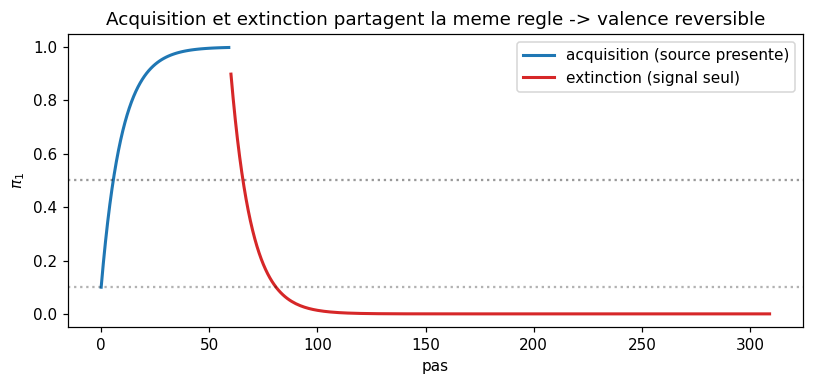

acquired=0.995 -> extinguished=0.000  reversible=1.0


In [5]:
# Acquisition puis extinction : meme courbe, symetrie parfaite.
lv2 = LearnedValence(n_signals=3, lr=0.1)
acq, ext = [], []
for _ in range(60):
    lv2.condition(1, source_valence=1.0, steps=1)
    acq.append(lv2.valence(1))
for _ in range(250):
    lv2.condition(1, source_valence=0.0, steps=1)
    ext.append(lv2.valence(1))

fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.plot(range(60), acq, lw=2, label="acquisition (source presente)")
ax.plot(range(60, 60 + 250), ext, lw=2, color="C3", label="extinction (signal seul)")
ax.axhline(0.5, ls=":", color="k", alpha=0.4)
ax.axhline(0.1, ls=":", color="k", alpha=0.3)
ax.set_xlabel("pas")
ax.set_ylabel(r"$\pi_1$")
ax.set_title("Acquisition et extinction partagent la meme regle -> valence reversible")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

rep_ext = extinction_test(n_signals=3, conditioned_idx=1, source_valence=1.0,
                          n_condition=50, n_extinction=200, lr=0.1)
print(f"acquired={rep_ext['acquired_valence']:.3f} -> extinguished={rep_ext['extinguished_valence']:.3f}  reversible={rep_ext['reversible']:.1f}")


## 5. Exercices

Trois exercices pour rendre la valence apprise opératoire. Chaque stub s'exécute sans erreur (C.1) — complétez-le.

### Exercice 1 — Conditionnement de second ordre

Le transfert #7740 est de *premier ordre* (source $\to$ signal neutre). Le conditionnement pavlovien admet aussi le *second ordre* : un signal déjà attractif peut transférer sa valence à un **autre** signal neutre (signal B co-occurrent avec signal A déjà conditionné, sans la source). Implémentez ce protocole et mesurez si $\pi_B$ monte (et de combien, vs le premier ordre).

*Indice* : conditionnez A avec la source, puis conditionnez B « via » A en passant `source_valence=pi_A` (la valence acquise de A devient la nouvelle source).


In [6]:
# Exercice 1 : conditionnement de second ordre.
# TODO etudiant : implementer le protocole decrit ci-dessus.
result = None  # TODO etudiant : (pi_B_second_ordre, pi_B_premier_ordre) pour comparaison
print("Exercice 1 a completer : mesurer pi_B en second ordre vs premier ordre.")
if result is not None:
    print(f"second ordre = {result[0]:.3f}, premier ordre = {result[1]:.3f}")


Exercice 1 a completer : mesurer pi_B en second ordre vs premier ordre.


### Exercice 2 — Seuil de taux d'apprentissage

Pour un budget fixé de `n_condition` présentations, il existe un **taux d'apprentissage** en dessous duquel le transfert échoue (la valence n'atteint pas 0.5). Trouvez ce seuil empiriquement pour `n_condition=50` par dichotomie.

*Indice* : la convergence Rescorla-Wagner après $n$ pas donne $\pi \approx v_\text{source}(1-(1-\mathrm{lr})^n)$ ; résolvez pour le `lr` qui donne $\pi = 0.5$, puis vérifiez avec `valence_transfer_test`.


In [7]:
# Exercice 2 : seuil de taux d'apprentissage pour n_condition=50.
# TODO etudiant : trouver lr_seuil tel que transfer_test(lrn) bascule autour.
lr_seuil = None  # TODO etudiant : valeur empirique
print("Exercice 2 a completer : seuil de lr pour n_condition=50.")
if lr_seuil is not None:
    r = valence_transfer_test(n_signals=4, neutral_idx=1, source_valence=1.0, n_condition=50, lr=lr_seuil)
    print(f"lr={lr_seuil:.4f} -> transferred={r['transferred']:.1f}")


Exercice 2 a completer : seuil de lr pour n_condition=50.


### Exercice 3 — Un prédicteur subtilement couplé

Le banc de distinctness accepte un prédicteur `predict_fn(i, pi_t)`. Construire un prédicteur **partiellement** couplé — qui lit la valence mais avec un poids $\alpha \in (0,1)$ : $p̂ = \alpha (1-\pi_i) + (1-\alpha) c_i$. Pour quel $\alpha$ le verdict `distinct` bascule-t-il de 1 à 0 ? Cela quantifie *combien* de couplage il faut pour que valence et prédiction deviennent indistinguables.

*Indice* : le seuil du banc est $|\Delta_\mathrm{err}| < 10^{-6}$. Calculez $\Delta_\mathrm{err}(\alpha)$ analytiquement puis confirmez en balayant $\alpha$.


In [8]:
# Exercice 3 : seuil de couplage alpha.
# TODO etudiant : balayer alpha et trouver le bascule du verdict distinct.
alpha_seuil = None  # TODO etudiant : valeur de alpha ou distinct bascule
print("Exercice 3 a completer : seuil de couplage alpha pour distinctness.")
if alpha_seuil is not None:
    print(f"alpha_seuil = {alpha_seuil}")


Exercice 3 a completer : seuil de couplage alpha pour distinctness.


## Conclusion

La valence **apprise** complète la valence **programmée** d'ICT-12 sans s'y réduire : même formalisme ($\pi_t$), mais **acquise** par Rescorla-Wagner plutôt qu'inscrite, donc *transférable* (un neutre devient attractif par association) et *réversible* (extinction par la même règle). Et cruciallement **distincte de la prédiction** : le banc `valence_prediction_distinctness_test` rend ce verdict réfutable dans les deux sens — un prédicteur invariant satisfait `distinct`, un re-vêtement de $\pi$ par $p̂$ le fait basculer à 0.

C'est le grain #7740 (« l'expérience manquante ») : opérationnaliser l'**investissement** thomien — non pas *où sera la proie* ($p̂$), mais *combien l'agent investit* dans un signal ($\pi$). Le module `ict.learned_valence` est la brique ; ce notebook la met en scène. Les strates suivantes (argumentation #7289, jeu évolutif #7746) reprendront cette valence apprise comme source de prégnance transférable.
